# Tech Challenge - Fase 1

## Desafio

Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

## Objetivo

Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

## Patologia escolhida para o desafio: Acidente Vascular Cerebral (AVC)

### O que é o AVC

O Acidente Vascular Cerebral (AVC) é uma condição em que o fluxo de sangue para uma parte do cérebro é interrompido. Como as células cerebrais dependem de oxigênio e nutrientes trazidos pelo sangue, essa interrupção pode causar danos neurológicos em poucos minutos.

### Tipos de AVC

1. AVC Isquêmico

- Ocorre quando um vaso sanguíneo é bloqueado por um coágulo.
- É o tipo mais comum.
- Geralmente relacionado a aterosclerose, fibrilação atrial e fatores de risco cardiovasculares.

2. AVC Hemorrágico
- Acontece quando um vaso sanguíneo se rompe, causando sangramento no cérebro.
- Pode ser causado por hipertensão não controlada, aneurismas ou malformações vasculares.

### Base de Dados - NHANES (https://www.cdc.gov/nchs/nhanes)

O NHANES (National Health and Nutrition Examination Survey) é uma base de dados pública conduzida pelo CDC (Centers for Disease Control and Prevention) dos Estados Unidos, voltada à avaliação do estado de saúde e nutricional da população norte-americana.

De forma breve:

- Natureza: estudo observacional, transversal, com amostragem probabilística representativa da população dos EUA.

- Periodicidade: realizado continuamente, organizado em ciclos bienais (ex.: 2017–2018 https://wwwn.cdc.gov/Nchs/Nhanes/continuousnhanes/default.aspx?BeginYear=2017).

- Conteúdo: combina

    - Questionários (doenças autorreferidas, estilo de vida, tabagismo, diabetes, histórico de AVC),

    - Exames físicos (pressão arterial, IMC, medidas corporais),

    - Exames laboratoriais (glicemia, hemoglobina glicada, colesterol, triglicerídeos, marcadores inflamatórios).

- Formato dos dados: arquivos modulares (.XPT), integrados por um identificador único do participante (SEQN).

- Aspecto metodológico importante: inclui pesos amostrais e variáveis de desenho complexo, permitindo inferência populacional.

No contexto acadêmico, o NHANES é amplamente utilizado para modelagem de risco cardiovascular e de AVC, epidemiologia, análise de fatores de risco e aplicações de machine learning em saúde, sendo valorizado pela qualidade dos dados, transparência metodológica e acesso aberto.

**Importando a base de dados**

In [116]:
import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

cycle_map = {
    "2011-2012": "G",
    "2013-2014": "H",
    "2015-2016": "I",
    "2017-2018": "J"
}

modules = {  # dicionário que mapeia nomes lógicos para templates de arquivos XPT
    "demo": "DEMO_{}.XPT",  # arquivo DEMO (dados demográficos): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm (ajustado para usar a letra do ciclo)
    "bpx": "BPX_{}.XPT",     # arquivo BPX (medidas de pressão arterial): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm
    "bpq": "BPQ_{}.XPT", # arquivo BPQ (pressão arterial e colesterol): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm
    "ocq": "OCQ_{}.XPT",     # arquivo OCQ (questionário de ocupação): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/OCQ_J.htm
    "ghb": "GHB_{}.XPT",     # arquivo GHB (hemoglobina glicada): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm
    "bmx": "BMX_{}.XPT",     # arquivo BMX (medidas corporais): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm
    "smq": "SMQ_{}.XPT",     # arquivo SMQ (questionário de tabagismo): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm
    "mcq": "MCQ_{}.XPT"     # arquivo de questionário médico (histórico de doenças): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm
}

dfs = {name: [] for name in modules}  # dicionário de listas para armazenar os DataFrames de cada módulo por ciclo

cycles = list(cycle_map.keys())  # lista de ciclos (ex.: ["2011-2012", "2017-2018"])

for cycle in cycles:
    letter = cycle_map[cycle]  # obtém a letra do ciclo (ex.: "G" para "2011-2012")
    year = cycle.split('-')[0]  # obtém o ano inicial do ciclo (ex.: "2011" para "2011-2012")
    base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/" + year + "/DataFiles/"  # URL base para os arquivos NHANES, usando o ano inicial
    for name, file_template in modules.items():  # itera sobre (nome, template de arquivo) do dicionário modules
        file = file_template.format(letter)  # formata o template com a letra do ciclo (ex.: "DEMO_G.XPT")
        print(f"Carregando {file} para o ciclo {cycle}...")
        dfs[name].append(pd.read_sas(base_url + file))  # lê o arquivo XPT remoto e adiciona à lista de dfs[name]

# concatena os DataFrames de cada módulo de todos os ciclos
demo_df = pd.concat(dfs["demo"], ignore_index=True)
bpx_df = pd.concat(dfs["bpx"], ignore_index=True)
bpq_df = pd.concat(dfs["bpq"], ignore_index=True)
ocq_df = pd.concat(dfs["ocq"], ignore_index=True)
ghb_df = pd.concat(dfs["ghb"], ignore_index=True)
bmx_df = pd.concat(dfs["bmx"], ignore_index=True)
smq_df = pd.concat(dfs["smq"], ignore_index=True)
mcq_df = pd.concat(dfs["mcq"], ignore_index=True)

# inicia com o DataFrame 'demo' concatenado e faz merges left sucessivos com os outros DataFrames concatenados usando 'SEQN' como chave
df = demo_df \
    .merge(bpx_df, on="SEQN", how="left") \
    .merge(bpq_df, on="SEQN", how="left") \
    .merge(ocq_df, on="SEQN", how="left") \
    .merge(ghb_df, on="SEQN", how="left") \
    .merge(bmx_df, on="SEQN", how="left") \
    .merge(smq_df, on="SEQN", how="left") \
    .merge(mcq_df, on="SEQN", how="left")

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado


Carregando DEMO_G.XPT para o ciclo 2011-2012...
Carregando BPX_G.XPT para o ciclo 2011-2012...
Carregando BPQ_G.XPT para o ciclo 2011-2012...
Carregando OCQ_G.XPT para o ciclo 2011-2012...
Carregando GHB_G.XPT para o ciclo 2011-2012...
Carregando BMX_G.XPT para o ciclo 2011-2012...
Carregando SMQ_G.XPT para o ciclo 2011-2012...
Carregando MCQ_G.XPT para o ciclo 2011-2012...
Carregando DEMO_H.XPT para o ciclo 2013-2014...
Carregando BPX_H.XPT para o ciclo 2013-2014...
Carregando BPQ_H.XPT para o ciclo 2013-2014...
Carregando OCQ_H.XPT para o ciclo 2013-2014...
Carregando GHB_H.XPT para o ciclo 2013-2014...
Carregando BMX_H.XPT para o ciclo 2013-2014...
Carregando SMQ_H.XPT para o ciclo 2013-2014...
Carregando MCQ_H.XPT para o ciclo 2013-2014...
Carregando DEMO_I.XPT para o ciclo 2015-2016...
Carregando BPX_I.XPT para o ciclo 2015-2016...
Carregando BPQ_I.XPT para o ciclo 2015-2016...
Carregando OCQ_I.XPT para o ciclo 2015-2016...
Carregando GHB_I.XPT para o ciclo 2015-2016...
Carregando

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGY,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,PEASCST1,PEASCTM1,PEASCCT1,BPXCHR,BPQ150A,BPQ150B,BPQ150C,BPQ150D,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,BPXDI1,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ057,BPQ056,BPD058,BPQ059,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D,OCD150,OCQ180,OCQ210,OCD231,OCD241,OCQ260,OCD270,OCQ275,OCQ380,OCD390G,OCD391,OCD392,OCD395,OCQ510,OCQ520,OCQ530,OCQ540,OCQ550,OCQ560,OCQ570,OCQ580,OCQ600,OCQ610,OCQ630,OCQ640,OCQ660,OCQ670,LBXGH,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM,BMXHIP,BMIHIP,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMQ077,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ621,SMD630,SMQ660,SMQ664M,SMQ664C,SMQ664W,SMQ664B,SMQ664O,SMQ670,SMAQUEX2,SMQ078,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ848,SMQ852Q,SMQ852U,SMQ925,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ051,MCQ053,MCQ070,MCQ075,MCQ080,MCQ082,MCQ084,MCQ086,MCQ092,MCD093,MCQ140,MCQ149,MCQ160A,MCQ180A,MCQ195,MCQ160N,MCQ180N,MCQ160B,MCQ180B,MCQ160C,MCQ180C,MCQ160D,MCQ180D,MCQ160E,MCQ180E,MCQ160F,MCQ180F,MCQ160G,MCQ180G,MCQ160M,MCQ170M,MCQ180M,MCQ160K,MCQ170K,MCQ180K,MCQ160L,MCQ170L,MCQ180L,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240AA,MCQ240B,MCQ240BB,MCQ240C,MCQ240CC,MCQ240D,MCQ240DD,MCQ240DK,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,AGQ030,MCQ151,MCQ160O,MCQ203,MCQ206,OSQ230,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,62161.0,7.0,2.0,1.0,22.0,NaN,3.0,3.0,2.0,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,3.0,5.0,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,102641.406474,104236.582554,1.0,91.0,14.0,14.0,3.15,5.0,5.0,5.397605e-79,1.0,5.397605e-79,2.0,50.0,1.0,5.0,1.0,5.0,NaN,NaN,NaN,NaN,1.0,596.0,NaN,NaN,2.0,2.0,2.0,2.0,1.0,4.0,82.0,1.0,1.0,130.0,110.0,82.0,2.0,104.0,68.0,2.0,118.0,74.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,1.0,99999.0,2.0,16.0,14.0,4.0,12.0,2.0,NaN,2.0,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,5.1,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,23.3,NaN,40.2,NaN,35.0,NaN,32.5,NaN,81.0,NaN,17.7,17.9,NaN,NaN,17.8,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62162.0,7.0,2.0,2.0,3.0,NaN,1.0,1.0,1.0,3

In [117]:
df.shape

(39156, 328)

In [ ]:
# manter somente as colunas solicitadas (se existirem) e avisar se alguma estiver ausente
cols_to_keep = [
    "SEQN", # Respondent sequence number
    "RIAGENDR", # Gender (DEMO): 1 - Male, 2 - Female
    "RIDAGEYR", # Age in years at screening (DEMO): 0 YEARS - 150 YEARS
    "BPQ020", # Ever told you had high blood pressure (BPQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160B",  # Ever told had congestive heart failure (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "DMDMARTL", # Marital status (DEMO): 1 - Married, 2 - Widowed, 3 - Divorced, 4 - Separated, 5 - Never married, 6 - Living with partner
    "OCQ260", # Description of job/work situation (OCQ): 1 - An employee of a private company, business, or individual for wages, salary, or commission., 2 - A federal government employee, 3 - A state government employee, 4 - A local government employee, 5 - Self-employed in own business, Working without pay in family business or farm, 6 - Refused, 77 - Don't know, 99 - Refused
    "SMQ020", # Ever smoked a cigar even 1 time? (SMQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160F" # TARGET -> Ever told you had a stroke (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
]

missing = [c for c in cols_to_keep if c not in df.columns]
if missing:
    print("Aviso: colunas ausentes e que não foram selecionadas:", missing)

df = df[[c for c in cols_to_keep if c in df.columns]].copy()

# renomeia as colunas para nomes mais amigáveis
df = df.rename(columns={"SEQN": "id"})
df = df.rename(columns={"RIAGENDR": "gender"})
df = df.rename(columns={"RIDAGEYR": "age"})
df = df.rename(columns={"BPQ020": "high_bp"})
df = df.rename(columns={"MCQ160B": "chf"})
df = df.rename(columns={"DMDMARTL": "marital"})
df = df.rename(columns={"OCQ260": "occup"})
df = df.rename(columns={"SMQ020": "smoke"})
df = df.rename(columns={"MCQ160F": "stroke"})

df.shape

(39156, 12)

**Exploração de dados**

In [119]:
df.head(5)

,id,gender,age,high_bp,chf,marital,occup,sbp,hba1c,bmi,smoke,stroke
0,62161.0,1.0,22.0,2.0,2.0,5.0,4.0,110.0,5.1,23.3,2.0,2.0
1,62162.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,14.2,NaN,NaN
2,62163.0,1.0,14.0,NaN,NaN,NaN,NaN,112.0,5.5,17.3,NaN,NaN
3,62164.0,2.0,44.0,2.0,2.0,1.0,1.0,116.0,4.9,23.2,2.0,2.0
4,62165.0,2.0,14.0,NaN,NaN,NaN,NaN,110.0,5.9,27.2,NaN,NaN


In [120]:
# verificar as 20 colunas com mais valores ausentes
df.isnull().sum().sort_values(ascending=False).head(20)

occup      25844
chf        16540
stroke     16540
marital    16539
smoke      15636
high_bp    14030
hba1c      13997
sbp        11781
bmi         4738
age            0
id             0
gender         0
dtype: int64

In [121]:
# calcular o percentual de valores ausentes por coluna
total = len(df)
(df.isnull().sum() / total * 100).sort_values(ascending=False).head(20)

occup      66.002656
chf        42.241291
stroke     42.241291
marital    42.238737
smoke      39.932577
high_bp    35.831035
hba1c      35.746757
sbp        30.087343
bmi        12.100317
age         0.000000
id          0.000000
gender      0.000000
dtype: float64

<Axes: >

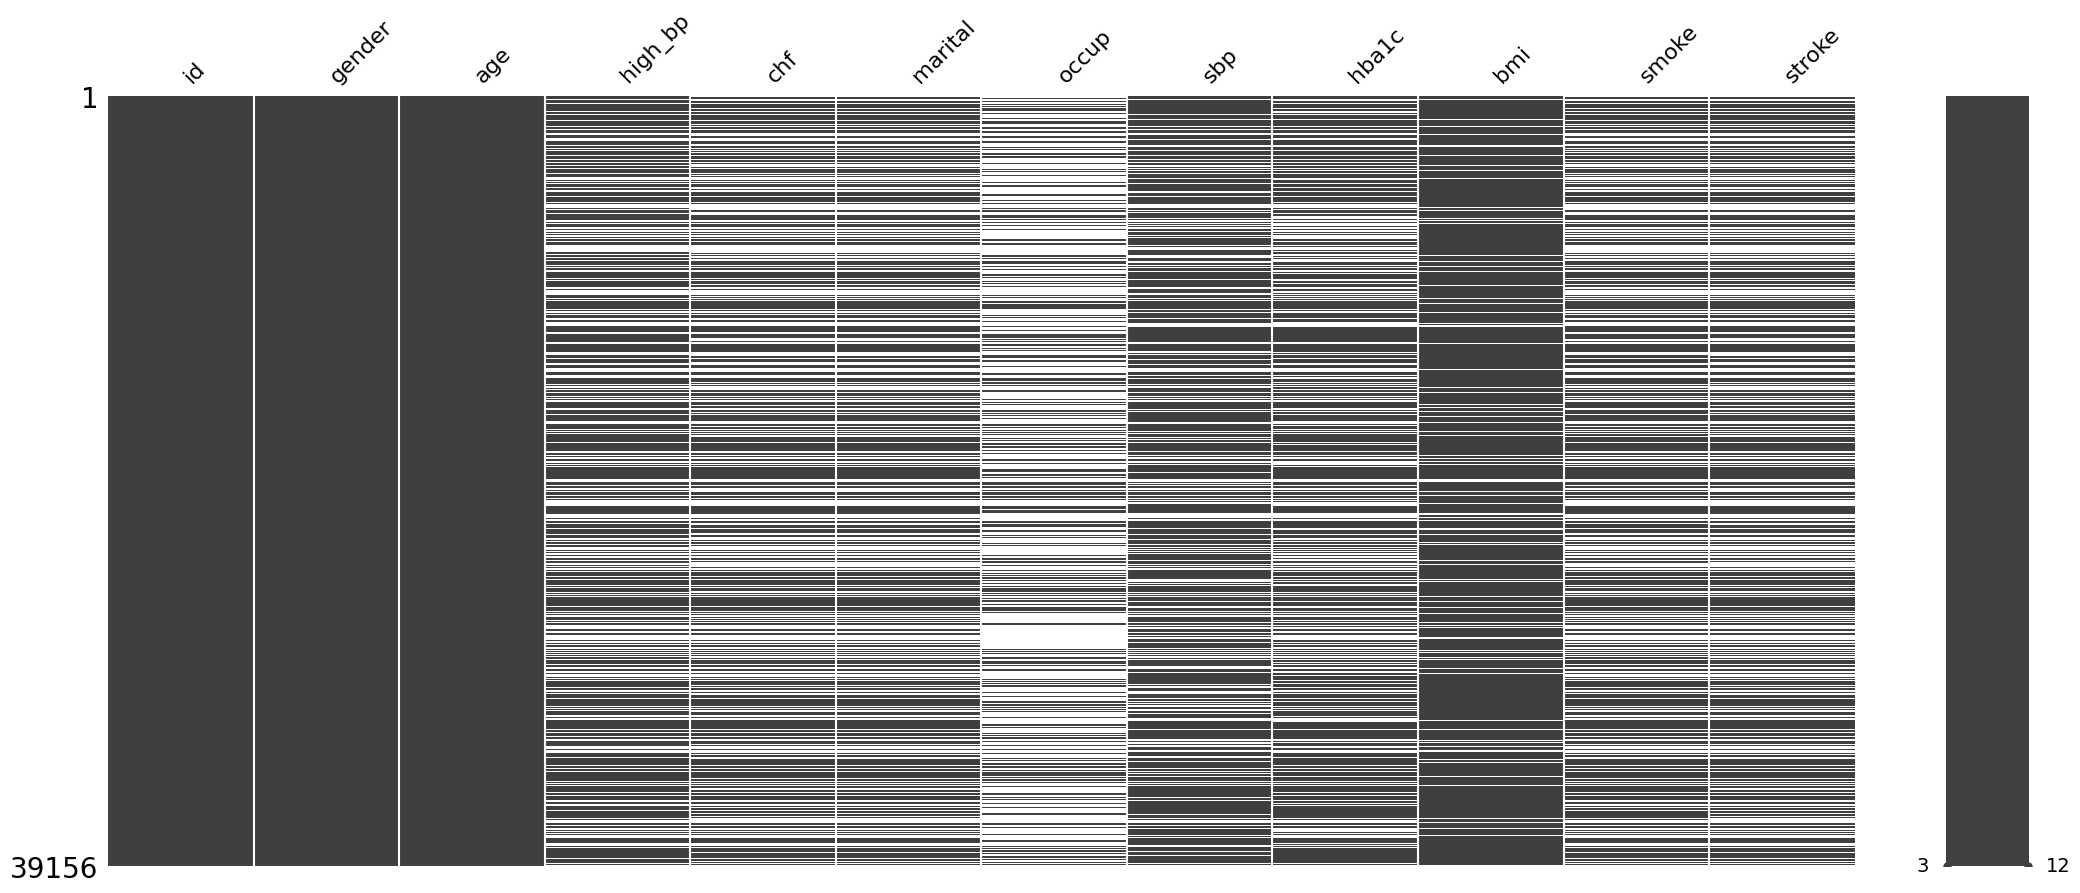

In [122]:
import missingno as msno
msno.matrix(df)

<Axes: >

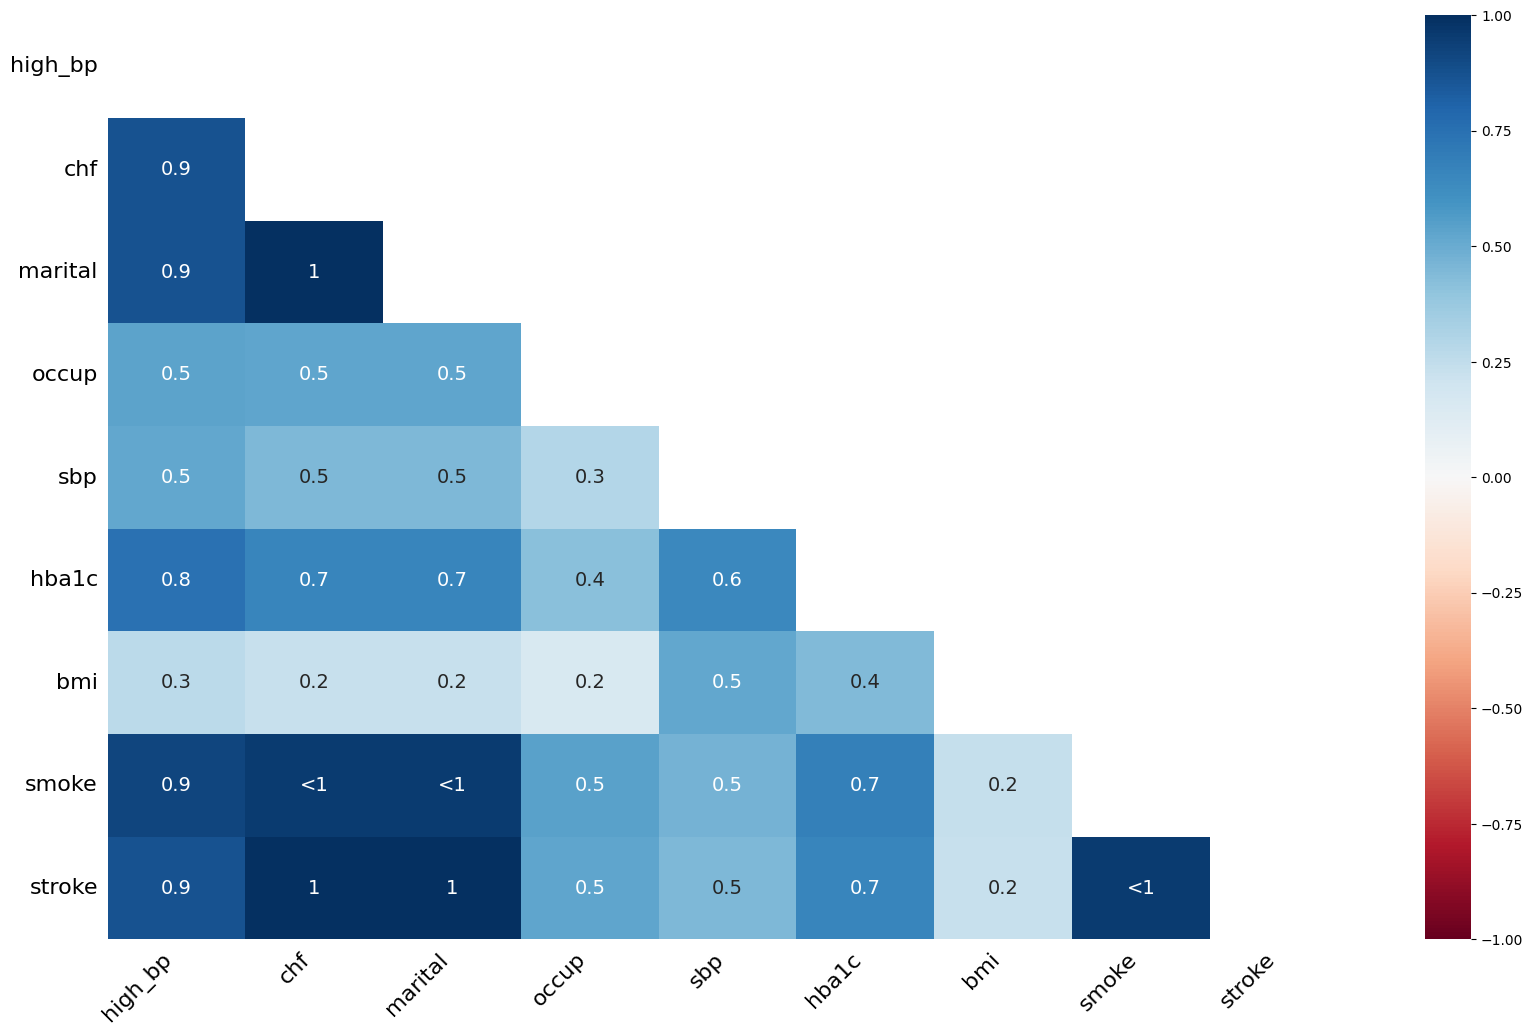

In [123]:
msno.heatmap(df)

In [124]:
df = df.dropna()
df.shape

(10580, 12)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10580 entries, 0 to 39152
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       10580 non-null  float64
 1   gender   10580 non-null  float64
 2   age      10580 non-null  float64
 3   high_bp  10580 non-null  float64
 4   chf      10580 non-null  float64
 5   marital  10580 non-null  float64
 6   occup    10580 non-null  float64
 7   sbp      10580 non-null  float64
 8   hba1c    10580 non-null  float64
 9   bmi      10580 non-null  float64
 10  smoke    10580 non-null  float64
 11  stroke   10580 non-null  float64
dtypes: float64(12)
memory usage: 1.0 MB


<Axes: >

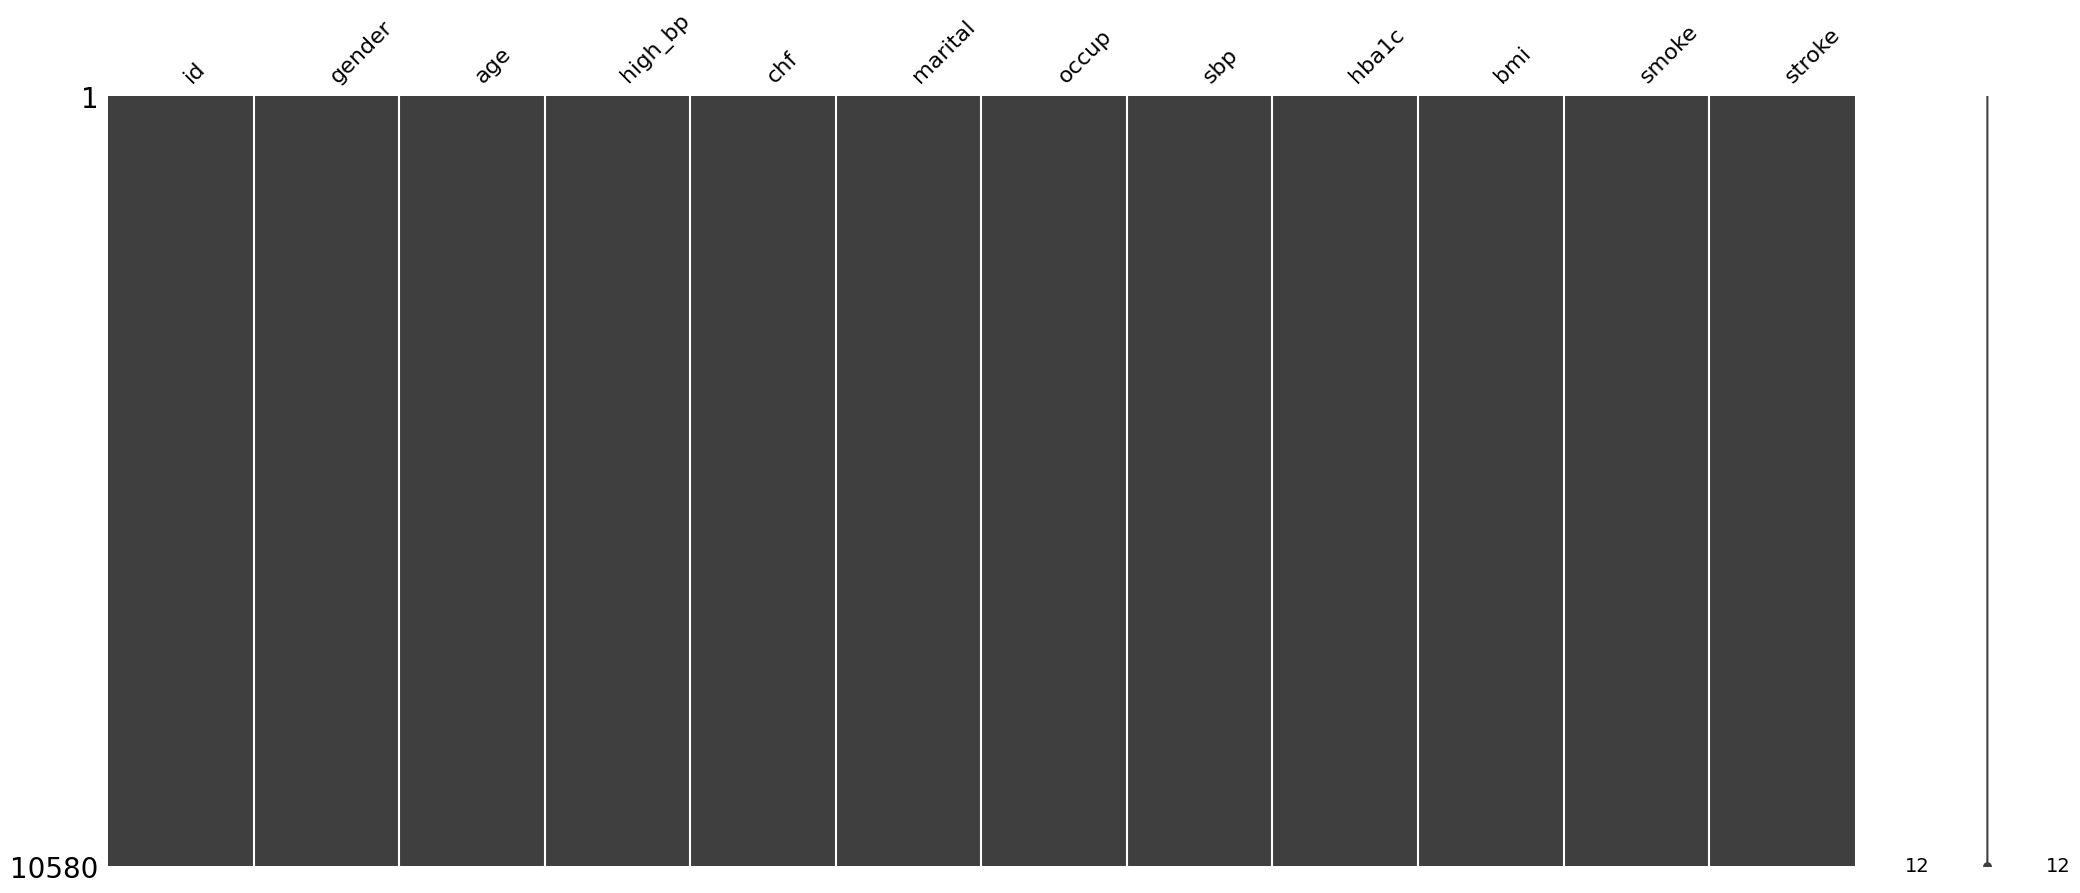

In [126]:
msno.matrix(df)

In [127]:
# verificar os valores únicos da coluna alvo
set(df.stroke)

{1.0, 2.0, 9.0}

In [ ]:
# manter só 1 (Yes) e 2 (No)
df = df[df['stroke'].isin([1, 2])].copy()
df['stroke'] = df['stroke'].map({1: 1, 2: 0})

df.shape

(10576, 12)

In [129]:
df.describe()

,id,gender,age,high_bp,chf,marital,occup,sbp,hba1c,bmi,smoke,stroke
count,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000,10576.000000
mean,83289.182300,1.468797,43.261725,1.740450,1.992152,2.696766,2.360155,121.651286,5.685269,29.149556,1.616017,0.010685
std,11641.116915,0.499049,14.181663,0.478822,0.135566,2.210966,7.736299,16.450979,1.045516,6.888008,0.512874,0.102817
min,62161.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,74.000000,3.600000,14.100000,1.000000,0.000000
25%,74157.750000,1.000000,31.000000,1.000000,2.000000,1.000000,1.000000,110.000000,5.200000,24.300000,1.000000,0.000000
50%,83858.500000,1.000000,43.000000,2.000000,2.000000,1.000000,1.000000,120.000000,5.500000,28.000000,2.000000,0.000000
75%,93073.250000,2.000000,54.000000,2.000000,2.000000,5.000000,2.000000,130.000000,5.800000,32.600000,2.000000,0.000000
max,102953.000000,2.000000,80.000000,9.000000,9.000000,77.000000,99.000000,238.000000,16.500000,80.600000,9.000000,1.000000


/tmp/ipykernel_11279/362378326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.boxplot(x='stroke', y='age', data=df, palette='hls')
/tmp/ipykernel_11279/362378326.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, '0 - não'), Text(1, 0, '1 - sim')]

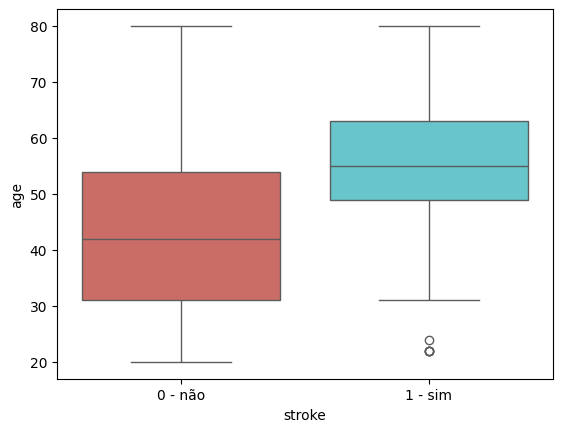

In [ ]:
import seaborn as sb

# Visualiza a distribuição de idade entre os pacientes com e sem histórico de derrame
sb.boxplot(x='stroke', y='age', data=df, palette='hls')

/tmp/ipykernel_11279/3089508675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='stroke', y='gender', data=df, palette='hls')


<Axes: xlabel='stroke', ylabel='gender'>

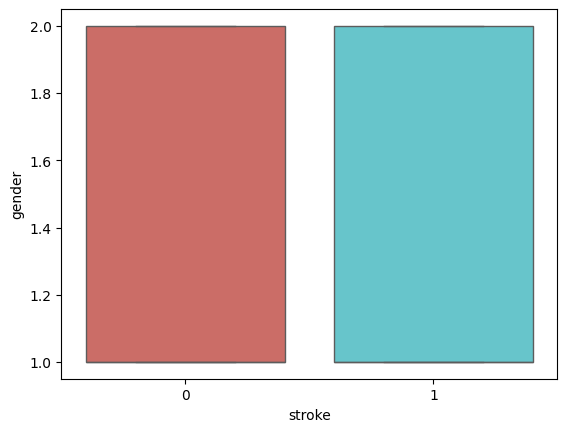

In [ ]:
# Visualiza a distribuição da pressão arterial sistólica entre os pacientes com e sem histórico de derrame
# sb.boxplot(x='stroke', y='gender', data=df, palette='hls')

**Analisando as variáveis numéricas**

## Referências

- https://pandascouple.medium.com/projeto-machine-learning-previs%C3%A3o-de-avc-f4b7dce11929
- https://jornal.usp.br/radio-usp/uso-de-ia-e-analise-de-dados-na-prevencao-de-avc-e-ataque-isquemico-transitorio/
- https://www.nature.com/articles/s41598-024-61665-4?error=cookies_not_supported&code=1d85f26e-6ade-4ec5-9132-5511aa615597&_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://jhi.sbis.org.br/index.php/jhi-sbis/article/view/980
- https://www.nature.com/articles/s41598-025-01855-w
